In [4]:
#import tips dataset
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


/tmp/ipykernel_1585/3537221678.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_bill = tips.groupby("day")["total_bill"].mean()


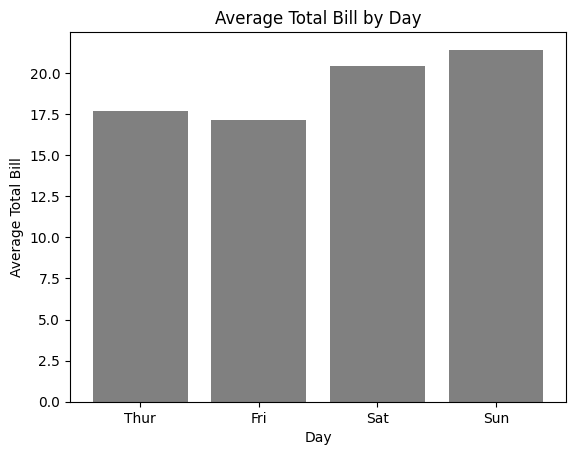

In [11]:
# @title
#Task1:Plot the bar chart of the dataset
avg_bill = tips.groupby("day")["total_bill"].mean()

plt.bar(avg_bill.index, avg_bill.values,color='grey')
plt.xlabel("Day")
plt.ylabel("Average Total Bill")
plt.title("Average Total Bill by Day")
plt.show()

/tmp/ipykernel_1585/1205324034.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_tip = tips.groupby("time")["tip"].mean()


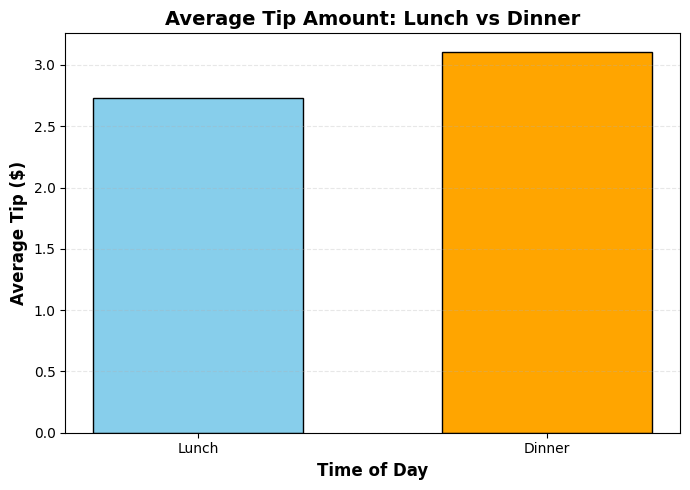

In [13]:
#Task1:Plot the bar chart of the dataset
avg_tip = tips.groupby("time")["tip"].mean()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    avg_tip.index,
    avg_tip.values,
    color=["skyblue", "orange"],
    edgecolor="black",
    width=0.6
)

plt.xlabel("Time of Day", fontsize=12, fontweight="bold")
plt.ylabel("Average Tip ($)", fontsize=12, fontweight="bold")
plt.title("Average Tip Amount: Lunch vs Dinner", fontsize=14, fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

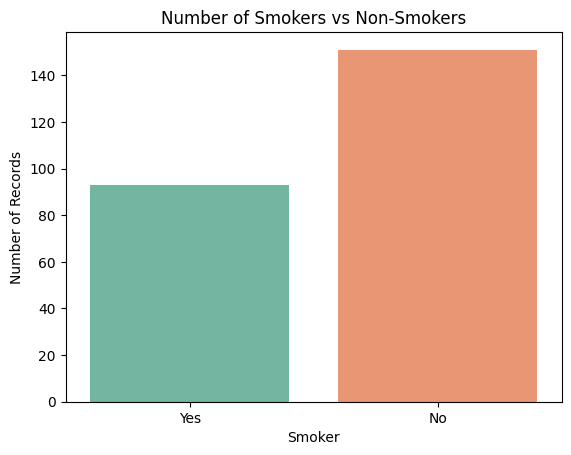

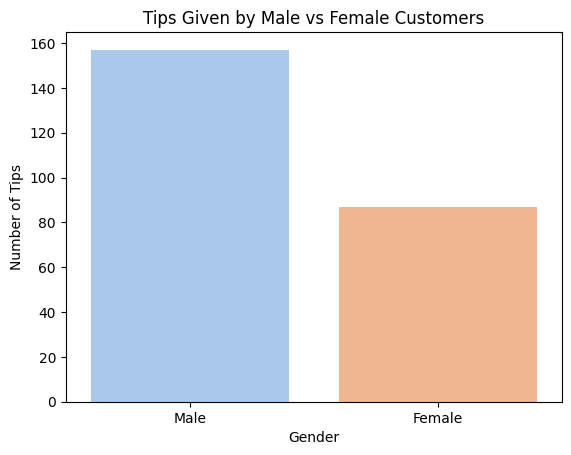

In [15]:
#Task2:create count plot
#smoker vs nonsmoker
sns.countplot(data=tips, x="smoker", hue="smoker", palette="Set2", legend=False)

plt.xlabel("Smoker")
plt.ylabel("Number of Records")
plt.title("Number of Smokers vs Non-Smokers")
plt.show()

#female vs male tips
sns.countplot(data=tips, x="sex", hue="sex", palette="pastel", legend=False)

plt.xlabel("Gender")
plt.ylabel("Number of Tips")
plt.title("Tips Given by Male vs Female Customers")
plt.show()

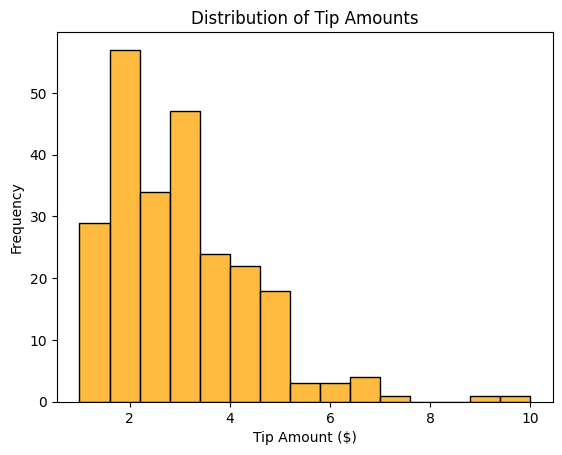

In [18]:
#Task3:Make histogram
sns.histplot(data=tips, x="tip", bins=15, color="orange", edgecolor="black")

plt.xlabel("Tip Amount ($)")
plt.ylabel("Frequency")
plt.title("Distribution of Tip Amounts")
plt.show()

Q1: 2.0
Q3: 3.5625
IQR: 1.5625
Lower Bound: -0.34375
Upper Bound: 5.90625
Number of Outliers: 9


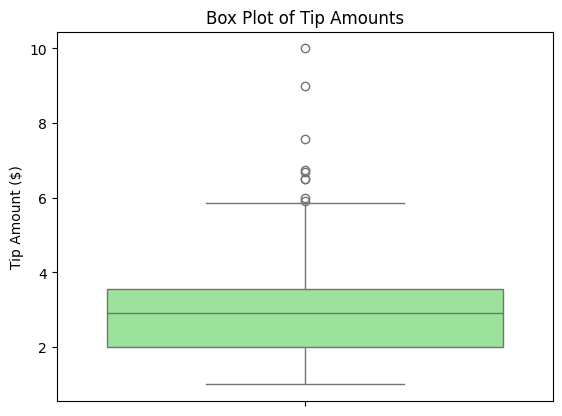

In [19]:
#Task 4 and 5:
Q1 = tips["tip"].quantile(0.25)
Q3 = tips["tip"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = tips[(tips["tip"] < lower) | (tips["tip"] > upper)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)
print("Number of Outliers:", len(outliers))

#Box plot
sns.boxplot(data=tips, y="tip", color="lightgreen")

plt.ylabel("Tip Amount ($)")
plt.title("Box Plot of Tip Amounts")
plt.show()

In [21]:
#Task 6:Outliers detection by Z score method
from scipy import stats

tips = sns.load_dataset("tips")

tips["zscore"] = stats.zscore(tips["tip"])

outliers_z = tips[tips["zscore"].abs() > 3]

print("Number of Z-score Outliers:", len(outliers_z))

Number of Z-score Outliers: 3


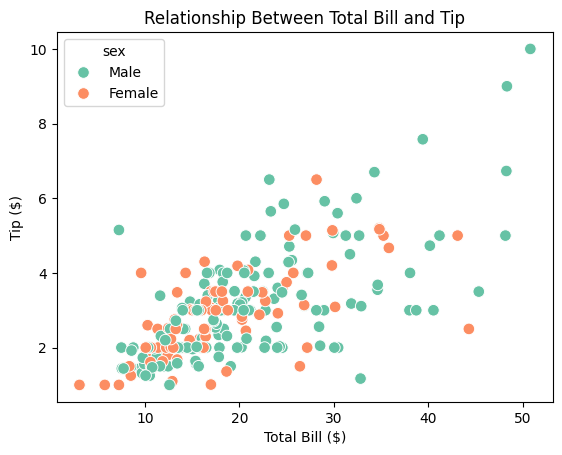

In [23]:
#task 7: Scatter plot

sns.scatterplot(data=tips, x="total_bill", y="tip", hue="sex", palette="Set2", s=70)

plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.title("Relationship Between Total Bill and Tip")
plt.show()

# There is a positive relationship between total bill and tip.
# As the total bill increases, the tip generally tends to increase as well.

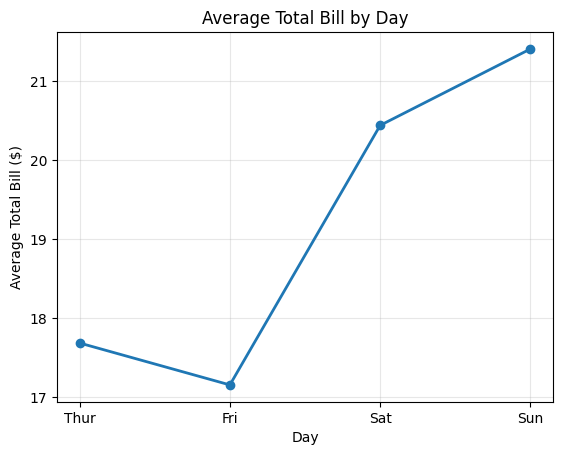

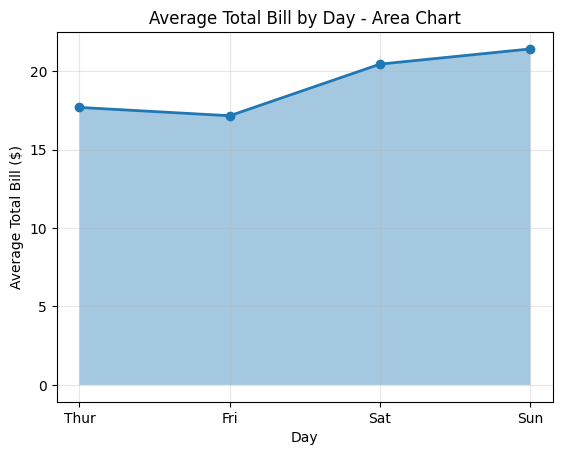

In [24]:
#Task8:Line/area chart
day_order = ["Thur", "Fri", "Sat", "Sun"]

avg_bill = tips.groupby("day", observed=False)["total_bill"].mean().reindex(day_order)

# Line Chart
plt.plot(avg_bill.index, avg_bill.values, marker="o", linewidth=2)

plt.xlabel("Day")
plt.ylabel("Average Total Bill ($)")
plt.title("Average Total Bill by Day")
plt.grid(alpha=0.3)
plt.show()

# Area Chart
plt.fill_between(avg_bill.index, avg_bill.values, alpha=0.4)
plt.plot(avg_bill.index, avg_bill.values, marker="o", linewidth=2)

plt.xlabel("Day")
plt.ylabel("Average Total Bill ($)")
plt.title("Average Total Bill by Day - Area Chart")
plt.grid(alpha=0.3)
plt.show()

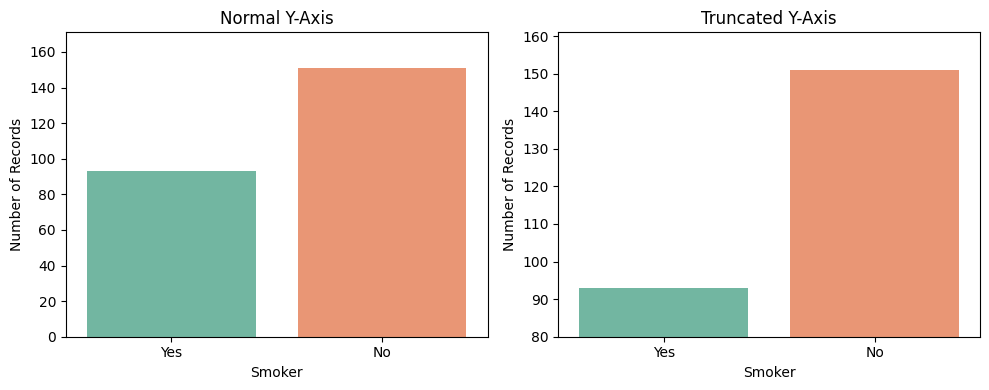

In [25]:
#Task 9: graphical integrity check:
counts = tips["smoker"].value_counts()

plt.figure(figsize=(10, 4))

# Normal chart
plt.subplot(1, 2, 1)
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="Set2", legend=False)
plt.xlabel("Smoker")
plt.ylabel("Number of Records")
plt.title("Normal Y-Axis")
plt.ylim(0, max(counts.values) + 20)

# Truncated chart
plt.subplot(1, 2, 2)
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="Set2", legend=False)
plt.xlabel("Smoker")
plt.ylabel("Number of Records")
plt.title("Truncated Y-Axis")
plt.ylim(80, max(counts.values) + 10)

plt.tight_layout()
plt.show()